Import Libraries

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split 
from xgboost import XGBRegressor 
from sklearn import metrics 
from sklearn.preprocessing import LabelEncoder 
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.svm import SVC

DATA COLLECTIONS

In [2]:
file_path = (r'dataset9000.csv')
df = pd.read_csv(file_path)

DATA ANALYS

In [3]:
df

,Database Fundamentals,Computer Architecture,Distributed Computing Systems,Cyber Security,Networking,Software Development,Programming Skills,Project Management,Computer Forensics Fundamentals,Technical Communication,AI ML,Software Engineering,Business Analysis,Communication skills,Data Science,Troubleshooting skills,Graphics Designing,Role
0,Professional,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Database Administrator
1,Professional,Poor,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Database Administrator
2,Professional,Beginner,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Database Administrator
3,Professional,Average,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Database Administrator
4,Professional,Intermediate,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Database Administrator
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9174,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Poor,Poor,Professional,Graphics Designer
9175,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Beginner,Beginner,Professional,Graphics Designer
9176,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Average,Average,Professional,Graphics Designer
9177,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Intermediate,Intermediate,Professional,Graphics Designer


In [4]:
df.shape

(9179, 18)

In [5]:
df.columns

Index(['Database Fundamentals', 'Computer Architecture',
       'Distributed Computing Systems', 'Cyber Security', 'Networking',
       'Software Development', 'Programming Skills', 'Project Management',
       'Computer Forensics Fundamentals', 'Technical Communication', 'AI ML',
       'Software Engineering', 'Business Analysis', 'Communication skills',
       'Data Science', 'Troubleshooting skills', 'Graphics Designing', 'Role'],
      dtype='str')

In [6]:
df.head()

,Database Fundamentals,Computer Architecture,Distributed Computing Systems,Cyber Security,Networking,Software Development,Programming Skills,Project Management,Computer Forensics Fundamentals,Technical Communication,AI ML,Software Engineering,Business Analysis,Communication skills,Data Science,Troubleshooting skills,Graphics Designing,Role
0,Professional,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Database Administrator
1,Professional,Poor,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Database Administrator
2,Professional,Beginner,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Database Administrator
3,Professional,Average,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Database Administrator
4,Professional,Intermediate,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Database Administrator


In [7]:
df.tail()

,Database Fundamentals,Computer Architecture,Distributed Computing Systems,Cyber Security,Networking,Software Development,Programming Skills,Project Management,Computer Forensics Fundamentals,Technical Communication,AI ML,Software Engineering,Business Analysis,Communication skills,Data Science,Troubleshooting skills,Graphics Designing,Role
9174,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Poor,Poor,Professional,Graphics Designer
9175,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Beginner,Beginner,Professional,Graphics Designer
9176,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Average,Average,Professional,Graphics Designer
9177,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Intermediate,Intermediate,Professional,Graphics Designer
9178,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Excellent,Excellent,Professional,Graphics Designer


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9179 entries, 0 to 9178
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   Database Fundamentals            9179 non-null   str  
 1   Computer Architecture            9179 non-null   str  
 2   Distributed Computing Systems    9179 non-null   str  
 3   Cyber Security                   9179 non-null   str  
 4   Networking                       9179 non-null   str  
 5   Software Development             9179 non-null   str  
 6   Programming Skills               9179 non-null   str  
 7   Project Management               9179 non-null   str  
 8   Computer Forensics Fundamentals  9179 non-null   str  
 9   Technical Communication          9179 non-null   str  
 10  AI ML                            9179 non-null   str  
 11  Software Engineering             9179 non-null   str  
 12  Business Analysis                9179 non-null   str  
 13 

In [9]:
df.describe()

,Database Fundamentals,Computer Architecture,Distributed Computing Systems,Cyber Security,Networking,Software Development,Programming Skills,Project Management,Computer Forensics Fundamentals,Technical Communication,AI ML,Software Engineering,Business Analysis,Communication skills,Data Science,Troubleshooting skills,Graphics Designing,Role
count,9179,9179,9179,9179,9179,9179,9179,9179,9179,9179,9179,9179,9179,9179,9179,9179,9179,9179
unique,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,17
top,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Poor,Database Administrator
freq,1440,1440,1440,1440,1440,1440,1440,1440,1440,1440,1440,1440,1440,1440,1440,1440,1441,540


In [10]:
df.isnull().sum()

Database Fundamentals              0
Computer Architecture              0
Distributed Computing Systems      0
Cyber Security                     0
Networking                         0
Software Development               0
Programming Skills                 0
Project Management                 0
Computer Forensics Fundamentals    0
Technical Communication            0
AI ML                              0
Software Engineering               0
Business Analysis                  0
Communication skills               0
Data Science                       0
Troubleshooting skills             0
Graphics Designing                 0
Role                               0
dtype: int64

In [11]:
df.duplicated().sum()
# duplicates = df[df.duplicated(keep=False)]
# print(duplicates)

np.int64(1426)

In [12]:
df['Networking'].value_counts()

Networking
Not Interested    1440
Poor              1440
Beginner          1440
Average           1440
Intermediate      1440
Excellent         1439
Professional       540
Name: count, dtype: int64

In [13]:
df['Role'].value_counts()

Role
Database Administrator             540
Hardware Engineer                  540
Application Support Engineer       540
Cyber Security Specialist          540
Networking Engineer                540
Software Developer                 540
API Specialist                     540
Project Manager                    540
Information Security Specialist    540
Technical Writer                   540
AI ML Specialist                   540
Software tester                    540
Business Analyst                   540
Customer Service Executive         540
Data Scientist                     540
Helpdesk Engineer                  540
Graphics Designer                  539
Name: count, dtype: int64

In [14]:
df['Role'].nunique()

17

In [15]:
df['Role'].unique()

<StringArray>
[         'Database Administrator',               'Hardware Engineer',
    'Application Support Engineer',       'Cyber Security Specialist',
             'Networking Engineer',              'Software Developer',
                  'API Specialist',                 'Project Manager',
 'Information Security Specialist',                'Technical Writer',
                'AI ML Specialist',                 'Software tester',
                'Business Analyst',      'Customer Service Executive',
                  'Data Scientist',               'Helpdesk Engineer',
               'Graphics Designer']
Length: 17, dtype: str

In [16]:
df['Software Development'].nunique()

7

DATA PREPROCESS

In [17]:
df.drop_duplicates(inplace=True)

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df

,Database Fundamentals,Computer Architecture,Distributed Computing Systems,Cyber Security,Networking,Software Development,Programming Skills,Project Management,Computer Forensics Fundamentals,Technical Communication,AI ML,Software Engineering,Business Analysis,Communication skills,Data Science,Troubleshooting skills,Graphics Designing,Role
0,Professional,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Database Administrator
1,Professional,Poor,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Database Administrator
2,Professional,Beginner,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Database Administrator
3,Professional,Average,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Database Administrator
4,Professional,Intermediate,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Database Administrator
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9174,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Poor,Poor,Professional,Graphics Designer
9175,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Beginner,Beginner,Professional,Graphics Designer
9176,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Average,Average,Professional,Graphics Designer
9177,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Intermediate,Intermediate,Professional,Graphics Designer


In [20]:
df.shape

(7753, 18)

In [21]:
#label encoding the object columns.
# Store object column names
original_columns = df.select_dtypes(include='object').columns

# Initialize LabelEncoder
label_encoders = {}

# Apply LabelEncoder to each categorical variable
for col in original_columns:
    label_encoders[col] = LabelEncoder()
    df[col] = label_encoders[col].fit_transform(df[col])

# Print the mapping between original categories and numerical labels
for col, encoder in label_encoders.items():
    print(f"Mapping for column '{col}':")
    for label, category in enumerate(encoder.classes_):
        print(f"Label {label}: {category}")
    print("=====================")


Mapping for column 'Database Fundamentals':
Label 0: Average
Label 1: Beginner
Label 2: Excellent
Label 3: Intermediate
Label 4: Not Interested
Label 5: Poor
Label 6: Professional
Mapping for column 'Computer Architecture':
Label 0: Average
Label 1: Beginner
Label 2: Excellent
Label 3: Intermediate
Label 4: Not Interested
Label 5: Poor
Label 6: Professional
Mapping for column 'Distributed Computing Systems':
Label 0: Average
Label 1: Beginner
Label 2: Excellent
Label 3: Intermediate
Label 4: Not Interested
Label 5: Poor
Label 6: Professional
Mapping for column 'Cyber Security':
Label 0: Average
Label 1: Beginner
Label 2: Excellent
Label 3: Intermediate
Label 4: Not Interested
Label 5: Poor
Label 6: Professional
Mapping for column 'Networking':
Label 0: Average
Label 1: Beginner
Label 2: Excellent
Label 3: Intermediate
Label 4: Not Interested
Label 5: Poor
Label 6: Professional
Mapping for column 'Software Development':
Label 0: Average
Label 1: Beginner
Label 2: Excellent
Label 3: Inte

C:\Users\1264\AppData\Local\Temp\ipykernel_11812\2398225871.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  original_columns = df.select_dtypes(include='object').columns


In [22]:
df

,Database Fundamentals,Computer Architecture,Distributed Computing Systems,Cyber Security,Networking,Software Development,Programming Skills,Project Management,Computer Forensics Fundamentals,Technical Communication,AI ML,Software Engineering,Business Analysis,Communication skills,Data Science,Troubleshooting skills,Graphics Designing,Role
0,6,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,7
1,6,5,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,7
2,6,1,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,7
3,6,0,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,7
4,6,3,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9174,4,4,4,4,4,4,4,4,4,4,4,4,4,4,5,5,6,8
9175,4,4,4,4,4,4,4,4,4,4,4,4,4,4,1,1,6,8
9176,4,4,4,4,4,4,4,4,4,4,4,4,4,4,0,0,6,8
9177,4,4,4,4,4,4,4,4,4,4,4,4,4,4,3,3,6,8


In [23]:
df['Role']

0       7
1       7
2       7
3       7
4       7
       ..
9174    8
9175    8
9176    8
9177    8
9178    8
Name: Role, Length: 7753, dtype: int64

In [24]:
df.head()

,Database Fundamentals,Computer Architecture,Distributed Computing Systems,Cyber Security,Networking,Software Development,Programming Skills,Project Management,Computer Forensics Fundamentals,Technical Communication,AI ML,Software Engineering,Business Analysis,Communication skills,Data Science,Troubleshooting skills,Graphics Designing,Role
0,6,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,7
1,6,5,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,7
2,6,1,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,7
3,6,0,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,7
4,6,3,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,7


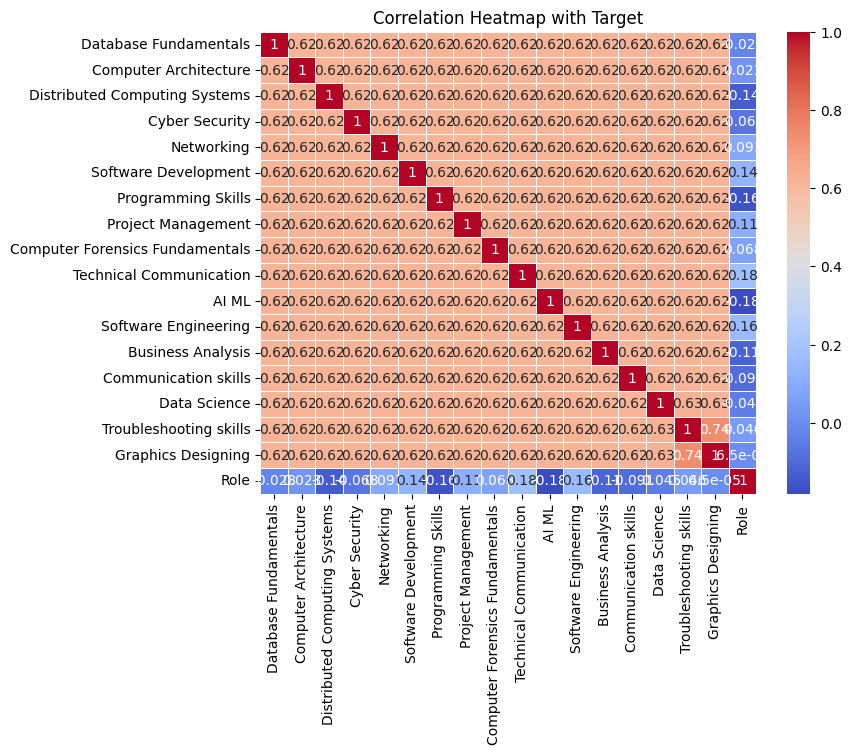

Correlation with Target Variable:
Database Fundamentals             -0.022733
Computer Architecture              0.022693
Distributed Computing Systems     -0.136301
Cyber Security                    -0.068160
Networking                         0.090834
Software Development               0.136260
Programming Skills                -0.159014
Project Management                 0.113547
Computer Forensics Fundamentals    0.068120
Technical Communication            0.181687
AI ML                             -0.181727
Software Engineering               0.158974
Business Analysis                 -0.113587
Communication skills              -0.090874
Data Science                      -0.045447
Troubleshooting skills             0.045512
Graphics Designing                 0.000065
Role                               1.000000
Name: Role, dtype: float64


In [25]:
# Calculate correlation matrix including the target variable
corr_matrix_with_target = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix_with_target, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap with Target')
plt.show()

# Print the correlation values with the target variable
print("Correlation with Target Variable:")
print(corr_matrix_with_target['Role'])

C:\Users\1264\AppData\Local\Temp\ipykernel_11812\2614349125.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Mutual Information', y='Feature', data=mi_df, palette='coolwarm')


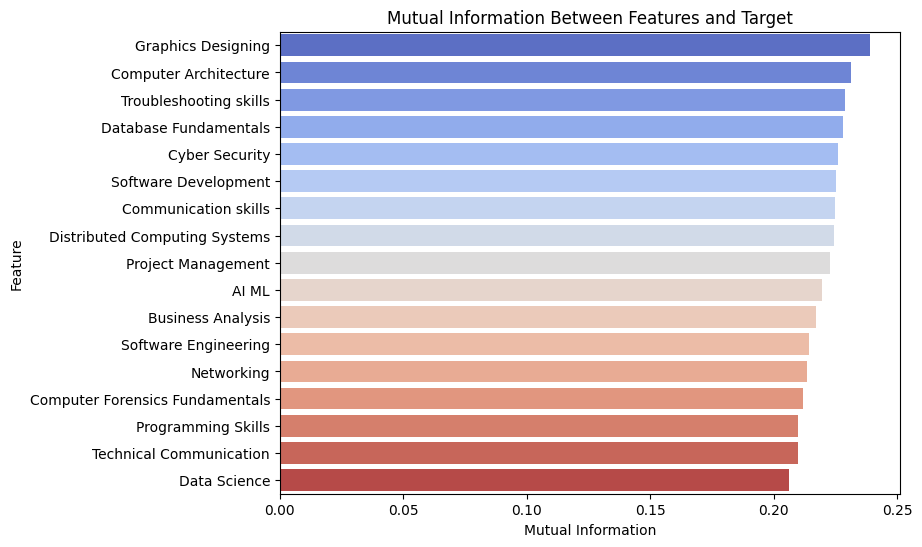

                            Feature  Mutual Information
16               Graphics Designing            0.239056
1             Computer Architecture            0.231068
15           Troubleshooting skills            0.228879
0             Database Fundamentals            0.227924
3                    Cyber Security            0.226051
5              Software Development            0.225272
13             Communication skills            0.224820
2     Distributed Computing Systems            0.224275
7                Project Management            0.222692
10                            AI ML            0.219436
12                Business Analysis            0.217269
11             Software Engineering            0.214130
4                        Networking            0.213597
8   Computer Forensics Fundamentals            0.212029
6                Programming Skills            0.209987
9           Technical Communication            0.209911
14                     Data Science            0

In [26]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate mutual information between each feature and the target variable
mi = mutual_info_classif(df.drop(columns='Role'), df['Role'])

# Create a DataFrame for visualization
mi_df = pd.DataFrame({'Feature': df.drop(columns='Role').columns, 'Mutual Information': mi})

# Sort the mutual information values
mi_df = mi_df.sort_values(by='Mutual Information', ascending=False)

# Plot mutual information
plt.figure(figsize=(8, 6))
sns.barplot(x='Mutual Information', y='Feature', data=mi_df, palette='coolwarm')
plt.title('Mutual Information Between Features and Target')
plt.show()

# Optionally, display the mutual information values
print(mi_df)

DATA SPLITTING

In [27]:
x = df.drop(['Role'], axis=1)
y = df['Role']

In [28]:
x

,Database Fundamentals,Computer Architecture,Distributed Computing Systems,Cyber Security,Networking,Software Development,Programming Skills,Project Management,Computer Forensics Fundamentals,Technical Communication,AI ML,Software Engineering,Business Analysis,Communication skills,Data Science,Troubleshooting skills,Graphics Designing
0,6,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4
1,6,5,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4
2,6,1,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4
3,6,0,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4
4,6,3,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9174,4,4,4,4,4,4,4,4,4,4,4,4,4,4,5,5,6
9175,4,4,4,4,4,4,4,4,4,4,4,4,4,4,1,1,6
9176,4,4,4,4,4,4,4,4,4,4,4,4,4,4,0,0,6
9177,4,4,4,4,4,4,4,4,4,4,4,4,4,4,3,3,6


In [29]:
y

0       7
1       7
2       7
3       7
4       7
       ..
9174    8
9175    8
9176    8
9177    8
9178    8
Name: Role, Length: 7753, dtype: int64

In [30]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [31]:
x_train

,Database Fundamentals,Computer Architecture,Distributed Computing Systems,Cyber Security,Networking,Software Development,Programming Skills,Project Management,Computer Forensics Fundamentals,Technical Communication,AI ML,Software Engineering,Business Analysis,Communication skills,Data Science,Troubleshooting skills,Graphics Designing
5233,1,1,1,1,5,1,1,1,1,6,1,1,1,1,1,1,1
5573,3,3,3,3,3,3,3,3,3,3,6,3,3,3,3,2,2
7391,5,5,5,5,5,5,5,5,2,5,5,5,5,6,5,5,5
4110,5,4,5,5,5,5,5,6,5,5,5,5,5,5,5,5,5
5957,1,1,1,1,1,1,1,1,1,1,1,6,2,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6185,3,3,2,3,3,3,3,3,3,3,3,6,3,3,3,3,3
6382,5,5,5,5,5,5,5,5,3,5,5,6,5,5,5,5,5
1018,5,6,5,5,5,5,5,5,5,5,5,5,5,5,5,3,3
9001,5,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,6


In [32]:
y_train

5233    16
5573     0
7391     4
4110    13
5957    15
        ..
6185    15
6382    15
1018     9
9001     8
8609    10
Name: Role, Length: 6202, dtype: int64

In [33]:
x_test

,Database Fundamentals,Computer Architecture,Distributed Computing Systems,Cyber Security,Networking,Software Development,Programming Skills,Project Management,Computer Forensics Fundamentals,Technical Communication,AI ML,Software Engineering,Business Analysis,Communication skills,Data Science,Troubleshooting skills,Graphics Designing
7763,0,0,0,0,2,0,0,0,0,0,0,0,0,0,6,0,0
6625,4,5,4,4,4,4,4,4,4,4,4,4,6,4,4,4,4
1919,5,5,5,6,5,5,5,5,5,5,5,5,2,5,5,5,5
5458,0,0,0,0,0,0,0,0,0,0,6,0,3,0,0,0,0
9093,4,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7507,0,0,0,0,0,0,0,0,0,0,0,5,0,6,0,0,0
8089,3,3,3,3,3,3,3,3,3,3,3,3,3,5,6,3,3
6460,1,1,1,1,1,1,1,1,1,1,3,6,1,1,1,1,1
3296,0,0,0,0,0,0,6,0,1,0,0,0,0,0,0,0,0


In [34]:
y_train

5233    16
5573     0
7391     4
4110    13
5957    15
        ..
6185    15
6382    15
1018     9
9001     8
8609    10
Name: Role, Length: 6202, dtype: int64

ALGORITHMS IMPLEMENTATION

XGBOOST

Training Accuracy of XGBoost: 0.96
Testing Accuracy of XGBoost: 0.95
Accuracy of XGBoost:  0.9529335912314636
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        87
           1       1.00      1.00      1.00        86
           2       1.00      1.00      1.00        95
           3       0.78      1.00      0.88        84
           4       1.00      1.00      1.00        93
           5       1.00      0.99      1.00       105
           6       1.00      1.00      1.00        98
           7       1.00      1.00      1.00        97
           8       1.00      1.00      1.00       100
           9       1.00      1.00      1.00        91
          10       0.86      1.00      0.93        81
          11       1.00      1.00      1.00        98
          12       0.98      1.00      0.99        84
          13       0.95      0.21      0.34        91
          14       1.00      1.00      1.00        91
          15       0.74  

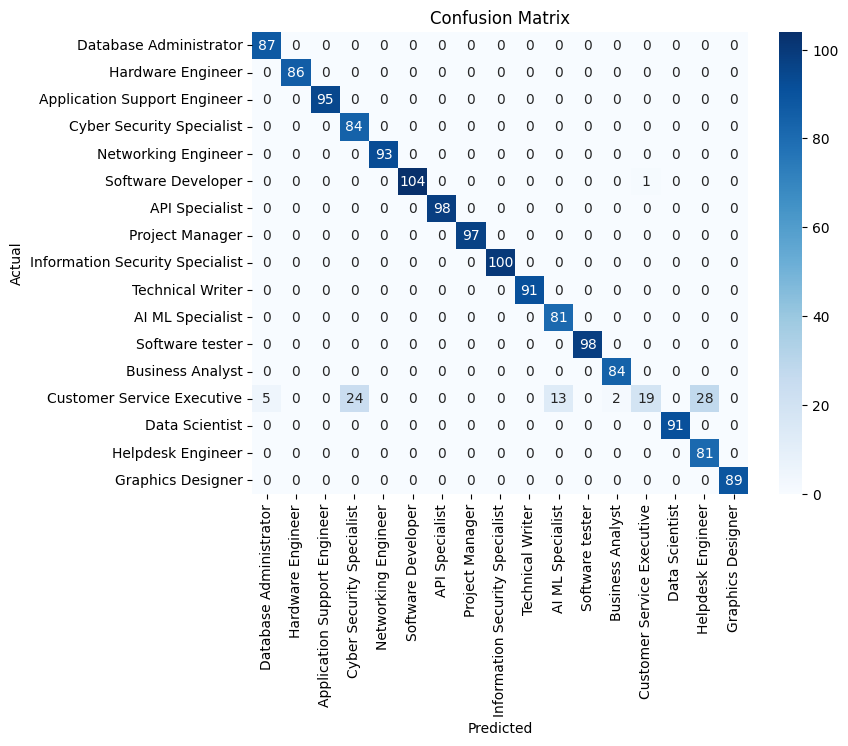

In [41]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize XGBoost Classifier with lower settings to reduce accuracy
# Initialize XGBoost Classifier with L1 and L2 regularization
xgb = XGBClassifier(
    n_estimators=7,  # Increase n_estimators
    learning_rate=0.01,  # Lower learning rate
    max_depth=6,  # Continue limiting tree depth
    reg_alpha=0.1,  # L1 regularization
    reg_lambda=0.1,  # L2 regularization
    random_state=42,
    subsample=0.1,  # Use 80% of the training data
    colsample_bytree=0.3  # Use 80% of the features for each tree
)


# Train the model on the training data
xgb.fit(x_train, y_train)

# Predict on training data
y_train_pred_xgb = xgb.predict(x_train)

# Predict on testing data
y_test_pred_xgb = xgb.predict(x_test)

# Compute accuracy on training data
train_accuracy_xgb = accuracy_score(y_train, y_train_pred_xgb)
print(f"Training Accuracy of XGBoost: {train_accuracy_xgb:.2f}")

# Compute accuracy on testing data
test_accuracy_xgb = accuracy_score(y_test, y_test_pred_xgb)
print(f"Testing Accuracy of XGBoost: {test_accuracy_xgb:.2f}")

accuracy_xgb = accuracy_score(y_test, y_test_pred_xgb)
result = classification_report(y_test, y_test_pred_xgb)

print("Accuracy of XGBoost: ", accuracy_xgb)
print(result)

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_test_pred_xgb)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Database Administrator', 'Hardware Engineer',
       'Application Support Engineer', 'Cyber Security Specialist',
       'Networking Engineer', 'Software Developer', 'API Specialist',
       'Project Manager', 'Information Security Specialist',
       'Technical Writer', 'AI ML Specialist', 'Software tester',
       'Business Analyst', 'Customer Service Executive', 'Data Scientist',
       'Helpdesk Engineer', 'Graphics Designer'], yticklabels=['Database Administrator', 'Hardware Engineer',
       'Application Support Engineer', 'Cyber Security Specialist',
       'Networking Engineer', 'Software Developer', 'API Specialist',
       'Project Manager', 'Information Security Specialist',
       'Technical Writer', 'AI ML Specialist', 'Software tester',
       'Business Analyst', 'Customer Service Executive', 'Data Scientist',
       'Helpdesk Engineer', 'Graphics Designer'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

RANDOM FOREST 

In [ ]:
from sklearn.ensemble import RandomForestClassifier
# Define the RandomForest Classifier

rf = RandomForestClassifier(
    n_estimators=6,  # Small number of trees to reduce complexity
    max_depth=5,  # Limit tree depth to avoid overfitting
    min_samples_split=10,  # Minimum samples required to split an internal node
    min_samples_leaf=5,  # Minimum samples required to be at a leaf node
    max_features='sqrt',  # Use square root of the number of features for each tree
    class_weight='balanced_subsample',  # Balanced class weights per bootstrap sample
    random_state=42,
    n_jobs=-1
)


# Train the rf on the training data
rf.fit(x_train, y_train)

# Predict on training data
y_train_pred_rf = rf.predict(x_train)

# Predict on testing data
y_test_pred_rf = rf.predict(x_test)

# Compute accuracy on training data
train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
print(f"Training Accuracy of Random Forest: {train_accuracy_rf:.2f}")

# Compute accuracy on testing data
test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)
print(f"Testing Accuracy of Random Forest: {test_accuracy_rf:.2f}")

accuracy_rf = accuracy_score(y_test, y_test_pred_rf)
result = classification_report(y_test, y_test_pred_rf)

print("Accuracy of Random Forest: ", accuracy_rf)
print(result)

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_test_pred_rf)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Database Administrator', 'Hardware Engineer',
       'Application Support Engineer', 'Cyber Security Specialist',
       'Networking Engineer', 'Software Developer', 'API Specialist',
       'Project Manager', 'Information Security Specialist',
       'Technical Writer', 'AI ML Specialist', 'Software tester',
       'Business Analyst', 'Customer Service Executive', 'Data Scientist',
       'Helpdesk Engineer', 'Graphics Designer'], yticklabels=['Database Administrator', 'Hardware Engineer',
       'Application Support Engineer', 'Cyber Security Specialist',
       'Networking Engineer', 'Software Developer', 'API Specialist',
       'Project Manager', 'Information Security Specialist',
       'Technical Writer', 'AI ML Specialist', 'Software tester',
       'Business Analyst', 'Customer Service Executive', 'Data Scientist',
       'Helpdesk Engineer', 'Graphics Designer'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()from sklearn.ensemble import RandomForestClassifier
# Define the RandomForest Classifier

rf = RandomForestClassifier(
    n_estimators=6,  # Small number of trees to reduce complexity
    max_depth=5,  # Limit tree depth to avoid overfitting
    min_samples_split=10,  # Minimum samples required to split an internal node
    min_samples_leaf=5,  # Minimum samples required to be at a leaf node
    max_features='sqrt',  # Use square root of the number of features for each tree
    class_weight='balanced_subsample',  # Balanced class weights per bootstrap sample
    random_state=42,
    n_jobs=-1
)


# Train the rf on the training data
rf.fit(x_train, y_train)

# Predict on training data
y_train_pred_rf = rf.predict(x_train)

# Predict on testing data
y_test_pred_rf = rf.predict(x_test)

# Compute accuracy on training data
train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
print(f"Training Accuracy of Random Forest: {train_accuracy_rf:.2f}")

# Compute accuracy on testing data
test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)
print(f"Testing Accuracy of Random Forest: {test_accuracy_rf:.2f}")

accuracy_rf = accuracy_score(y_test, y_test_pred_rf)
result = classification_report(y_test, y_test_pred_rf)

print("Accuracy of Random Forest: ", accuracy_rf)
print(result)

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_test_pred_rf)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Database Administrator', 'Hardware Engineer',
       'Application Support Engineer', 'Cyber Security Specialist',
       'Networking Engineer', 'Software Developer', 'API Specialist',
       'Project Manager', 'Information Security Specialist',
       'Technical Writer', 'AI ML Specialist', 'Software tester',
       'Business Analyst', 'Customer Service Executive', 'Data Scientist',
       'Helpdesk Engineer', 'Graphics Designer'], yticklabels=['Database Administrator', 'Hardware Engineer',
       'Application Support Engineer', 'Cyber Security Specialist',
       'Networking Engineer', 'Software Developer', 'API Specialist',
       'Project Manager', 'Information Security Specialist',
       'Technical Writer', 'AI ML Specialist', 'Software tester',
       'Business Analyst', 'Customer Service Executive', 'Data Scientist',
       'Helpdesk Engineer', 'Graphics Designer'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Training Accuracy of Random Forest: 1.00
Testing Accuracy of Random Forest: 1.00
Accuracy of Random Forest:  1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        87
           1       1.00      1.00      1.00        86
           2       1.00      1.00      1.00        95
           3       1.00      1.00      1.00        84
           4       1.00      1.00      1.00        93
           5       1.00      1.00      1.00       105
           6       1.00      1.00      1.00        98
           7       1.00      1.00      1.00        97
           8       1.00      1.00      1.00       100
           9       1.00      1.00      1.00        91
          10       1.00      1.00      1.00        81
          11       1.00      1.00      1.00        98
          12       1.00      1.00      1.00        84
          13       1.00      1.00      1.00        91
          14       1.00      1.00      1.00        91
          15       1.0

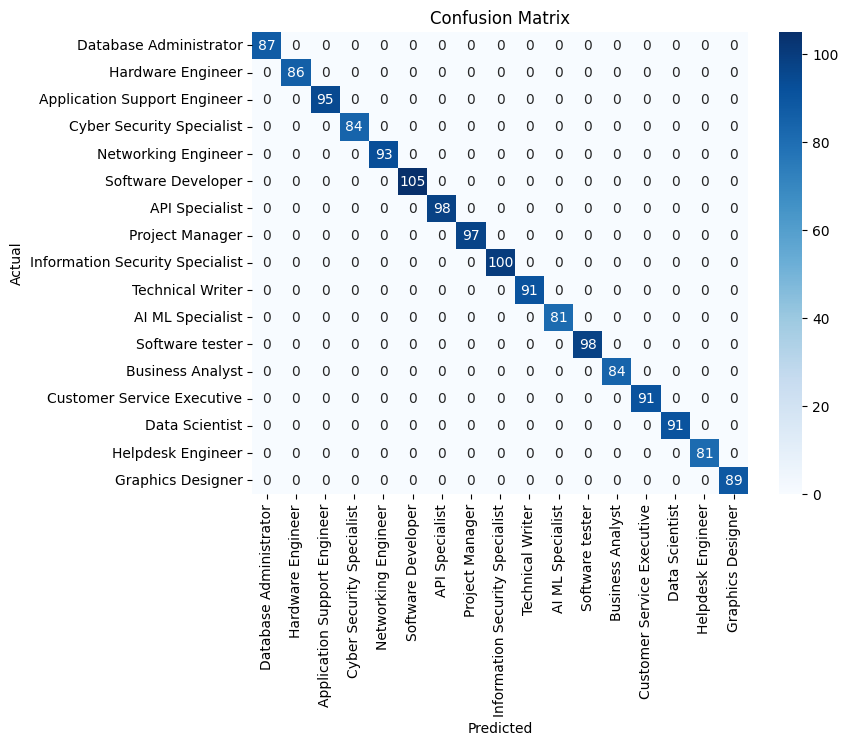

In [44]:
from sklearn.ensemble import RandomForestClassifier
# Define the RandomForest Classifier

rf = RandomForestClassifier(
)


# Train the rf on the training data
rf.fit(x_train, y_train)

# Predict on training data
y_train_pred_rf = rf.predict(x_train)

# Predict on testing data
y_test_pred_rf = rf.predict(x_test)

# Compute accuracy on training data
train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
print(f"Training Accuracy of Random Forest: {train_accuracy_rf:.2f}")

# Compute accuracy on testing data
test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)
print(f"Testing Accuracy of Random Forest: {test_accuracy_rf:.2f}")

accuracy_rf = accuracy_score(y_test, y_test_pred_rf)
result = classification_report(y_test, y_test_pred_rf)

print("Accuracy of Random Forest: ", accuracy_rf)
print(result)

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_test_pred_rf)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Database Administrator', 'Hardware Engineer',
       'Application Support Engineer', 'Cyber Security Specialist',
       'Networking Engineer', 'Software Developer', 'API Specialist',
       'Project Manager', 'Information Security Specialist',
       'Technical Writer', 'AI ML Specialist', 'Software tester',
       'Business Analyst', 'Customer Service Executive', 'Data Scientist',
       'Helpdesk Engineer', 'Graphics Designer'], yticklabels=['Database Administrator', 'Hardware Engineer',
       'Application Support Engineer', 'Cyber Security Specialist',
       'Networking Engineer', 'Software Developer', 'API Specialist',
       'Project Manager', 'Information Security Specialist',
       'Technical Writer', 'AI ML Specialist', 'Software tester',
       'Business Analyst', 'Customer Service Executive', 'Data Scientist',
       'Helpdesk Engineer', 'Graphics Designer'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# decision tree

Training Accuracy of Decision Tree: 1.00
Testing Accuracy of Decision Tree: 1.00
Accuracy of Decision Tree:  1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        87
           1       1.00      1.00      1.00        86
           2       1.00      1.00      1.00        95
           3       1.00      1.00      1.00        84
           4       1.00      1.00      1.00        93
           5       1.00      1.00      1.00       105
           6       1.00      1.00      1.00        98
           7       1.00      1.00      1.00        97
           8       1.00      1.00      1.00       100
           9       1.00      1.00      1.00        91
          10       1.00      1.00      1.00        81
          11       1.00      1.00      1.00        98
          12       1.00      1.00      1.00        84
          13       1.00      1.00      1.00        91
          14       1.00      1.00      1.00        91
          15       1.0

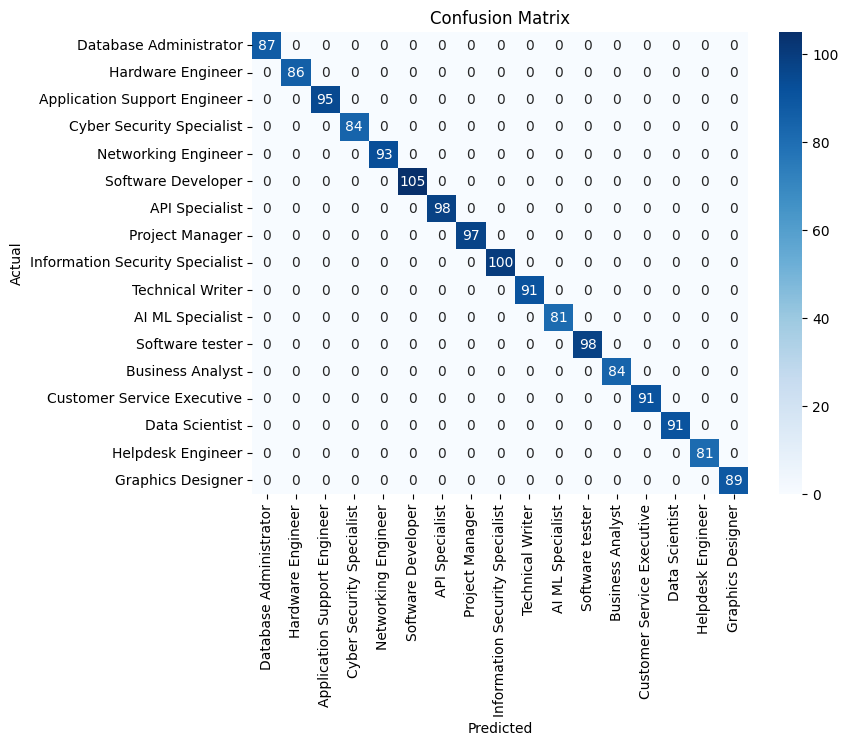

In [76]:
# Initialize the DecisionTreeClassifier
dt = DecisionTreeClassifier()

# Train the dt on the training data
dt.fit(x_train, y_train)

# Predict on training data
y_train_pred_dt = dt.predict(x_train)

# Predict on testing data
y_test_pred_dt = dt.predict(x_test)

# Compute accuracy on training data
train_accuracy_dt = accuracy_score(y_train, y_train_pred_dt)
print(f"Training Accuracy of Decision Tree: {train_accuracy_dt:.2f}")

# Compute accuracy on testing data
test_accuracy_dt = accuracy_score(y_test, y_test_pred_dt)
print(f"Testing Accuracy of Decision Tree: {test_accuracy_dt:.2f}")

accuracy_dt = accuracy_score(y_test, y_test_pred_dt)
result = classification_report(y_test, y_test_pred_dt)

print("Accuracy of Decision Tree: ", accuracy_dt)
print(result)

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_test_pred_dt)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Database Administrator', 'Hardware Engineer',
       'Application Support Engineer', 'Cyber Security Specialist',
       'Networking Engineer', 'Software Developer', 'API Specialist',
       'Project Manager', 'Information Security Specialist',
       'Technical Writer', 'AI ML Specialist', 'Software tester',
       'Business Analyst', 'Customer Service Executive', 'Data Scientist',
       'Helpdesk Engineer', 'Graphics Designer'], yticklabels=['Database Administrator', 'Hardware Engineer',
       'Application Support Engineer', 'Cyber Security Specialist',
       'Networking Engineer', 'Software Developer', 'API Specialist',
       'Project Manager', 'Information Security Specialist',
       'Technical Writer', 'AI ML Specialist', 'Software tester',
       'Business Analyst', 'Customer Service Executive', 'Data Scientist',
       'Helpdesk Engineer', 'Graphics Designer'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

SUPPORT VECTOR MACHINE (SVM)

Training Accuracy of Support Vector Machine: 1.00
Testing Accuracy of Support Vector Machine: 1.00
Accuracy of Support Vector Machine:  1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        87
           1       1.00      1.00      1.00        86
           2       1.00      1.00      1.00        95
           3       1.00      1.00      1.00        84
           4       1.00      1.00      1.00        93
           5       1.00      1.00      1.00       105
           6       1.00      1.00      1.00        98
           7       1.00      1.00      1.00        97
           8       1.00      1.00      1.00       100
           9       1.00      1.00      1.00        91
          10       1.00      1.00      1.00        81
          11       1.00      1.00      1.00        98
          12       1.00      1.00      1.00        84
          13       1.00      1.00      1.00        91
          14       1.00      1.00      1.00      

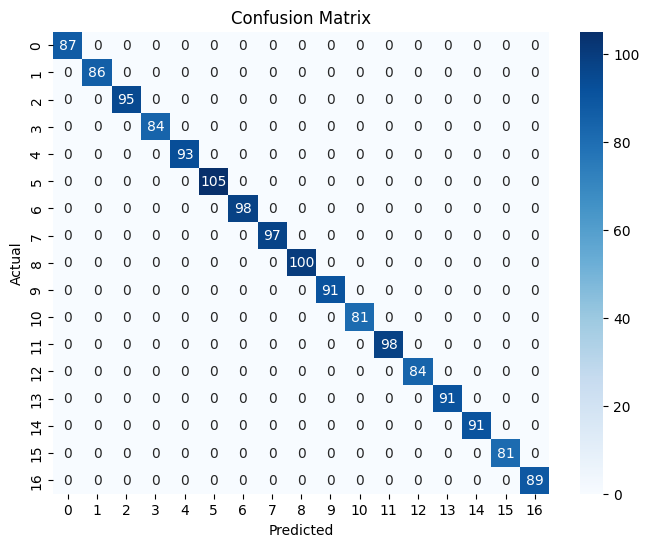

In [77]:
# Initialize the SVM classifier
svm = SVC(kernel='linear', random_state=42)

# Train the model
svm.fit(x_train, y_train)

# Predict on training data
y_train_pred_svm = svm.predict(x_train)

# Predict on testing data
y_test_pred_svm = svm.predict(x_test)

# Compute accuracy on training data
train_accuracy_svm = accuracy_score(y_train, y_train_pred_svm)
print(f"Training Accuracy of Support Vector Machine: {train_accuracy_svm:.2f}")

# Compute accuracy on testing data
test_accuracy_svm = accuracy_score(y_test, y_test_pred_svm)
print(f"Testing Accuracy of Support Vector Machine: {test_accuracy_svm:.2f}")

accuracy_svm = accuracy_score(y_test, y_test_pred_svm)
result = classification_report(y_test, y_test_pred_svm)

print("Accuracy of Support Vector Machine: ", accuracy_svm)
print(result)

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_test_pred_svm)
unique_classes = np.unique(y_test)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=unique_classes, yticklabels=unique_classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [78]:
conf_matrix

array([[ 87,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0],
       [  0,  86,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0],
       [  0,   0,  95,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0],
       [  0,   0,   0,  84,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0],
       [  0,   0,   0,   0,  93,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0],
       [  0,   0,   0,   0,   0, 105,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,  98,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  97,   0,   0,   0,   0,   0,
          0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0, 100,   0,   0,   0,   0,
          0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  91,   0,   0,   0,
         

# CNN

In [79]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.





Epoch 1/10


194/194 [==============================] - 4s 8ms/step - loss: 2.6065 - accuracy: 0.2967 - val_loss: 2.2019 - val_accuracy: 0.6196
Epoch 2/10
194/194 [==============================] - 1s 7ms/step - loss: 1.7811 - accuracy: 0.5618 - val_loss: 1.2552 - val_accuracy: 0.7834
Epoch 3/10
194/194 [==============================] - 1s 7ms/step - loss: 1.1431 - accuracy: 0.7207 - val_loss: 0.7905 - val_accuracy: 0.8698
Epoch 4/10
194/194 [==============================] - 1s 7ms/step - loss: 0.8070 - accuracy: 0.8099 - val_loss: 0.5578 - val_accuracy: 0.9104
Epoch 5/10
194/194 [==============================] - 1s 7ms/step - loss: 0.6087 - accuracy: 0.8617 - val_loss: 0.4067 - val_accuracy: 0.9529
Epoch 6/10
194/194 [==============================] - 1s 6ms/step - loss: 0.4810 - accuracy: 0.8992 - val_loss: 0.3095 - val_accuracy: 0.9613
Epoch 7/10
194/194 [==============================] - 1s 6ms/step - loss: 0.3774 - accuracy: 0.9226 - val_loss: 0.2384 - val_accuracy: 0.9774
E

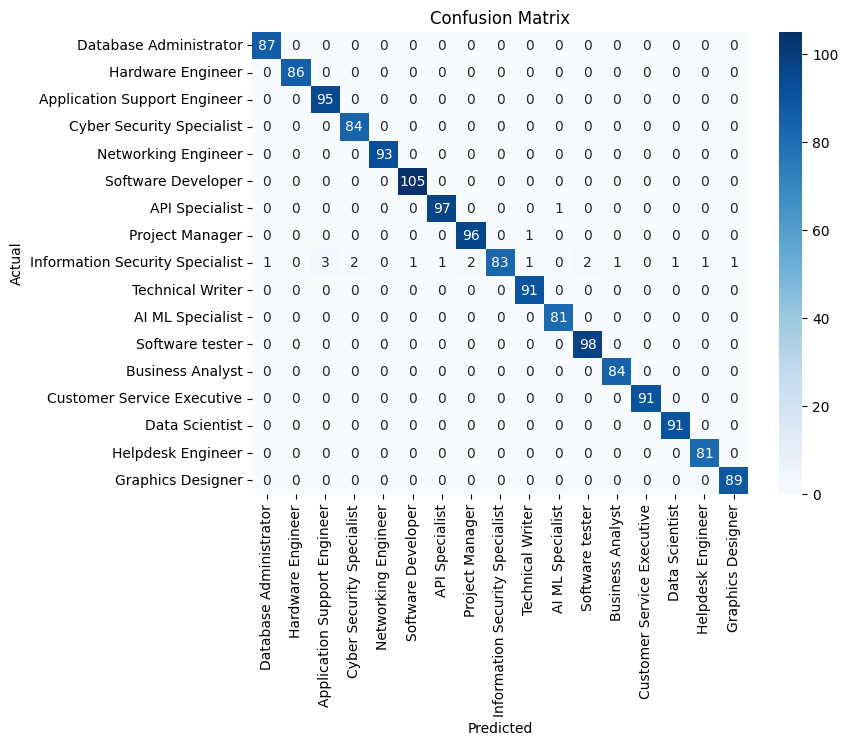

In [34]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight

# Assuming x and y are your features and target variable
# x = your feature set (shape: 9179, 18)
# y = your target variable (multi-class)

# 1. One-hot encode the target variable
y_encoded = to_categorical(y)  # This converts y to a one-hot encoded array

# 2. Scaling the data
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)  # Scale the features

# 3. Reshape the data to be in a 3D shape for CNN (samples, features, channels)
x_scaled = x_scaled.reshape(x_scaled.shape[0], x_scaled.shape[1], 1)  # Shape: (9179, 18, 1)

# 4. Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y_encoded, test_size=0.2, random_state=42)

# 5. Compute class weights to handle class imbalance
class_weights = compute_class_weight('balanced', classes=np.unique(np.argmax(y_train, axis=1)), y=np.argmax(y_train, axis=1))
class_weight_dict = dict(enumerate(class_weights))

# 6. Build the CNN Model
model = Sequential()

# First Conv Layer with more filters and kernel size
model.add(Conv1D(filters=128, kernel_size=5, activation='relu', input_shape=(x_train.shape[1], 1)))
model.add(MaxPooling1D(pool_size=2))  # Max Pooling Layer

# Second Conv Layer with more filters
model.add(Conv1D(filters=256, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(pool_size=2))

# Flatten the output from the Convolutional Layer
model.add(Flatten())

# Dense Layer with more neurons
model.add(Dense(128, activation='relu'))

# Add Dropout to prevent overfitting
model.add(Dropout(0.5))  # 50% dropout after the fully connected layers

# Output Layer (for multi-class classification, use softmax)
model.add(Dense(y_train.shape[1], activation='softmax'))  # y_train.shape[1] is the number of classes

# 7. Compile the Model with a lower learning rate
optimizer = Adam(learning_rate=0.0001)  # Lower learning rate
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])  # For multi-class classification

# 8. Train the Model with class weights
history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_test, y_test), class_weight=class_weight_dict)

# 9. Evaluate the Model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc:.2f}")

# 10. Predict on Test Data
y_test_pred_cnn = model.predict(x_test)

# Convert probabilities to class labels (highest probability class)
y_test_pred_cnn = np.argmax(y_test_pred_cnn, axis=1)

# Convert y_test back to class labels (from one-hot encoding)
y_test_labels = np.argmax(y_test, axis=1)

# Compute accuracy
train_accuracy_cnn = accuracy_score(np.argmax(y_train, axis=1), np.argmax(model.predict(x_train), axis=1))
print(f"Training Accuracy of CNN: {train_accuracy_cnn:.2f}")

test_accuracy_cnn = accuracy_score(y_test_labels, y_test_pred_cnn)
print(f"Testing Accuracy of CNN: {test_accuracy_cnn:.2f}")

accuracy_cnn = accuracy_score(y_test_labels, y_test_pred_cnn)
result = classification_report(y_test_labels, y_test_pred_cnn)

print("Accuracy of CNN: ", accuracy_cnn)
print(result)

# Confusion matrix
conf_matrix = confusion_matrix(y_test_labels, y_test_pred_cnn)
unique_classes = np.unique(y_test_labels)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Database Administrator', 'Hardware Engineer',
       'Application Support Engineer', 'Cyber Security Specialist',
       'Networking Engineer', 'Software Developer', 'API Specialist',
       'Project Manager', 'Information Security Specialist',
       'Technical Writer', 'AI ML Specialist', 'Software tester',
       'Business Analyst', 'Customer Service Executive', 'Data Scientist',
       'Helpdesk Engineer', 'Graphics Designer'], yticklabels=['Database Administrator', 'Hardware Engineer',
       'Application Support Engineer', 'Cyber Security Specialist',
       'Networking Engineer', 'Software Developer', 'API Specialist',
       'Project Manager', 'Information Security Specialist',
       'Technical Writer', 'AI ML Specialist', 'Software tester',
       'Business Analyst', 'Customer Service Executive', 'Data Scientist',
       'Helpdesk Engineer', 'Graphics Designer'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


ACCURACY COMPARISION GRAPH

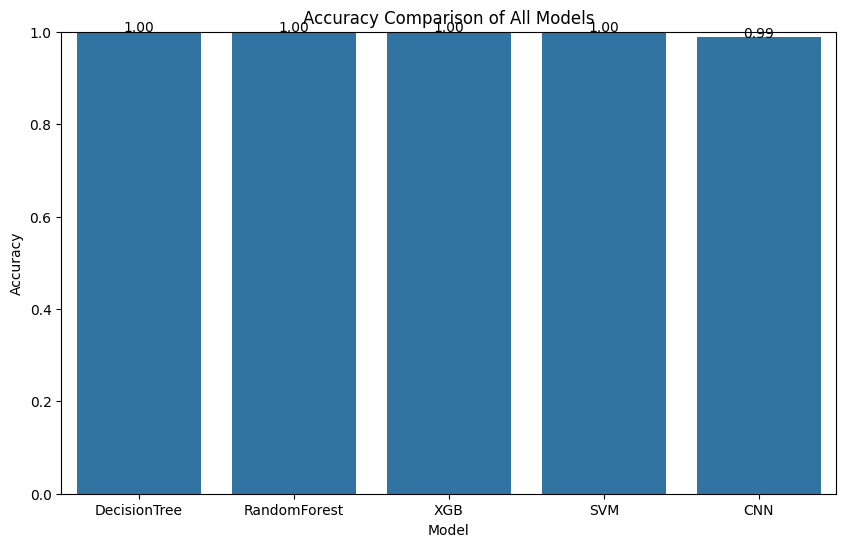

In [81]:
model_names = ['DecisionTree', 'RandomForest', 'XGB', 'SVM' , 'CNN']
accuracies = [accuracy_dt, accuracy_rf, accuracy_xgb, accuracy_svm, accuracy_cnn]

plt.figure(figsize=(10, 6))
sns.barplot(x=model_names, y=accuracies)
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison of All Models')
plt.ylim(0, 1)
for i in range(len(accuracies)):
    plt.text(i, accuracies[i], f'{accuracies[i]:.2f}', ha='center')
plt.show()

SAVE MODEL

In [82]:
import joblib

# Save RandomForest Classifier
joblib.dump(rf, 'models/RandomForest.joblib')

# Save XGBClassifier 
joblib.dump(xgb, 'models/XGBClassifier.joblib')

# Save SVM model
joblib.dump(svm, 'models/SVM.joblib')

# Save DecisionTree Classifier
joblib.dump(dt, 'models/DecisionTree.joblib')

# Save CNN model
joblib.dump(dt, 'models/DecisionTree.joblib')


['models/DecisionTree.joblib']